# Fit quality — calibrated e-ADM vs the Ding data

Loads the model written by `parameter_tuning.ipynb` and compares it against the Ding experiments
using ADToolbox's `optimize.validate_model`.

The **VFAs were fitted**, so §3–§4 are a training diagnostic, not evidence of generalisation.
**Methane was never fitted** (§5), so it is a genuine held-out check. For held-out VFA numbers see
§10 of `parameter_tuning.ipynb`.

## 1. Setup

In [1]:
from pathlib import Path
import json, csv
import numpy as np
import polars as pl

from adtoolbox import adm, core, optimize

REPO   = Path.cwd().parent if Path.cwd().name == "Examples" else Path.cwd()
MODEL  = REPO / "reference_data" / "calibrated_model.json"   # written by parameter_tuning.ipynb
STUDY  = REPO / "Examples" / "Studies" / "ding_experiments.json"
SOLVER = "BDF"          # Radau is unstable on the low-loading FW+AS condition

calibrated = adm.Model.load(MODEL)
calibrated.time_limit = 60
print("model:", calibrated.name, "|", len(calibrated.species), "species")

model: calibrated-e-ADM | 49 species


## 2. Experiments

`validate_model` applies each experiment's `base_parameters` and initial conditions but **not its
feed**, so the model would silently keep the feed it was saved with (`Default Feed`, 10%
carbohydrate) instead of Ding's food waste (50.1%). We set the feed per experiment below.

In [2]:
def to_experiment(entry):
    fd = entry["feed"]
    exp = core.Experiment(
        name=entry["name"], time=list(entry["time"]), variables=list(entry["variables"]),
        data=entry["data"],
        feed=core.Feed(name=fd["name"], carbohydrates=fd["carbohydrates"], lipids=fd["lipids"],
                       proteins=fd["proteins"], tss=fd["tss"], si=fd["si"], xi=fd["xi"]),
        initial_concentrations=entry["initial_concentrations"],
        base_parameters=entry["base_parameters"], constants=entry["constants"],
        reference=entry["reference"], model_name="e_adm")
    exp.condition = entry.get("condition", entry["name"])
    return exp

experiments = [to_experiment(e) for e in json.loads(STUDY.read_text()).values()]
conditions  = sorted({e.condition for e in experiments})
calibrated.sim_time = max(max(e.time) for e in experiments)

print(f"{len(experiments)} experiments | conditions: {conditions}")
print("fitted variables:", experiments[0].variables, "| feed:", experiments[0].feed.name)

6 experiments | conditions: ['FW+AS', 'FW+TWAS', 'FW+TWAS+AS']
fitted variables: ['S_ac', 'S_pro', 'S_bu', 'S_va', 'S_cap'] | feed: Foodwaste


## 3. VFA goodness of fit (training)

`optimize.calculate_fit_stats` exists but hardcodes the `Radau` solver, which blows up on FW+AS.
We call `optimize.validate_model` with `BDF` and compute R² / RMSE from the frames it returns.

In [3]:
def fit_frames(experiment):
    calibrated.feed = experiment.feed
    out, _ = optimize.validate_model(calibrated, experiment, plot=False, ode_solver=SOLVER)
    cols = experiment.variables
    return out["model"].select(cols).to_numpy(), out["data"].select(cols).to_numpy()

def stats(pairs):
    pred = np.concatenate([p.ravel() for p, _ in pairs])
    obs  = np.concatenate([o.ravel() for _, o in pairs])
    ss_res = float(np.sum((obs - pred) ** 2))
    return {"R2": 1 - ss_res / float(np.sum((obs - obs.mean()) ** 2)),
            "RMSE": float(np.sqrt(ss_res / obs.size))}

frames = {e.name: fit_frames(e) for e in experiments}
rows = [{"scope": "ALL", "n": len(experiments), **stats(list(frames.values()))}]
for cond in conditions:
    sub = [frames[e.name] for e in experiments if e.condition == cond]
    rows.append({"scope": cond, "n": len(sub), **stats(sub)})

pl.DataFrame(rows).with_columns(pl.col("R2").round(3), pl.col("RMSE").round(3))

scope,n,R2,RMSE
str,i64,f64,f64
"""ALL""",6,0.832,0.43
"""FW+AS""",2,0.637,0.497
"""FW+TWAS""",2,0.863,0.467
"""FW+TWAS+AS""",2,0.906,0.297


## 4. Predicted vs measured

One panel per reactor — lines are the model, markers are the measurements. `show_extra_states`
adds **`S_gas_ch4`**, which is never fitted, so it rides along as a free held-out check.

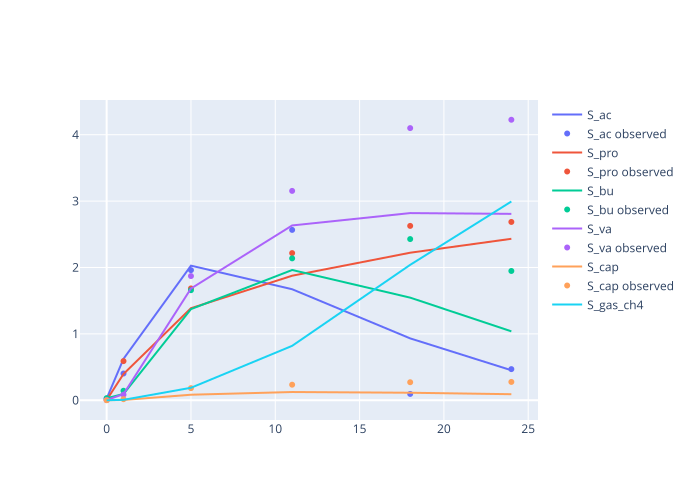

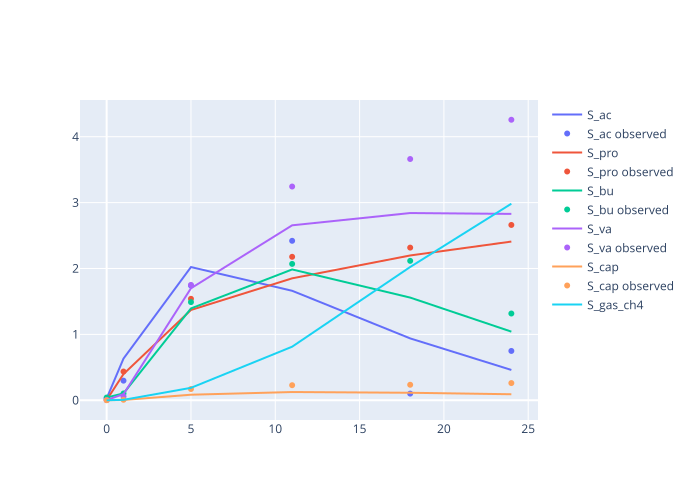

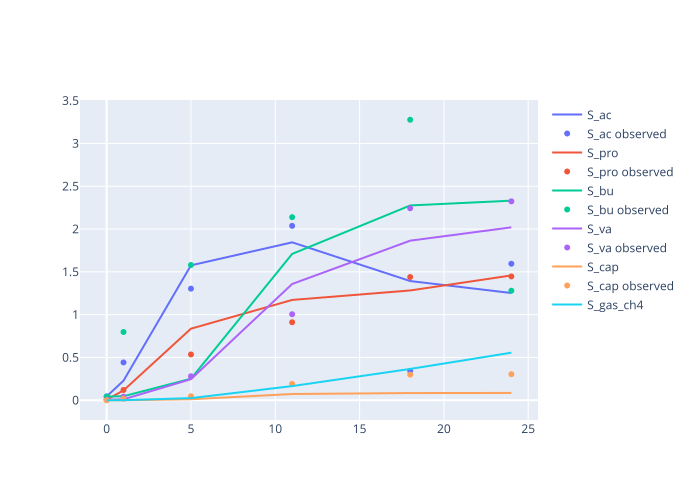

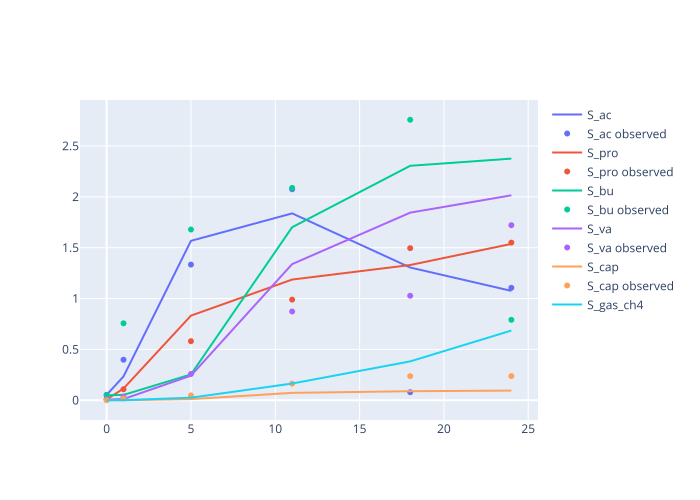

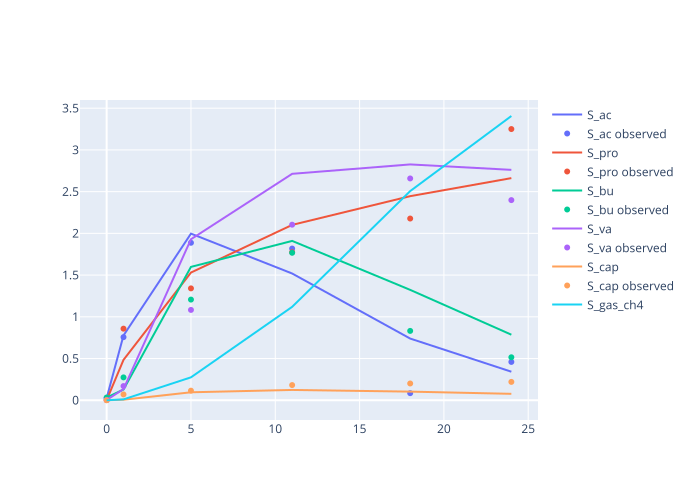

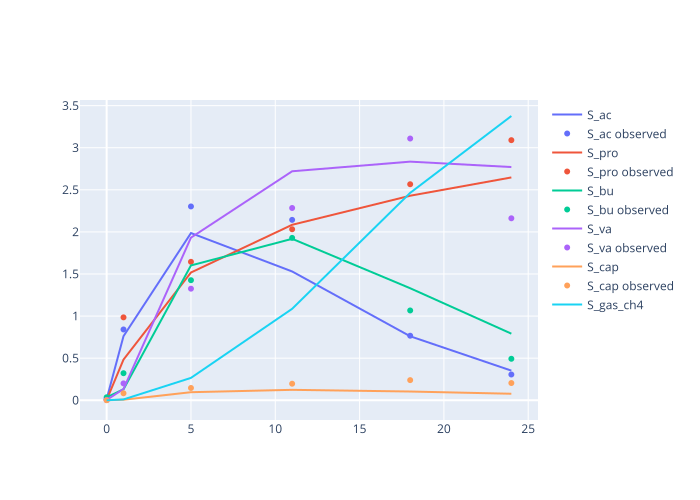

In [4]:
for experiment in experiments:
    calibrated.feed = experiment.feed
    _, fig = optimize.validate_model(calibrated, experiment, plot=True, ode_solver=SOLVER,
                                     show_extra_states=["S_gas_ch4"])
    fig.update_layout(title=f"{experiment.name} ({experiment.condition})",
                      xaxis_title="time (days)", yaxis_title="gCOD/L", height=380)
    fig.show()

## 5. Methane — held out

Methane was never in the objective, so agreement here is not fitted in.

Units differ: the model reports `S_gas_ch4` in gCOD/L, the paper reports cumulative mL CH₄. They
are compared **normalised to the strongest condition** — this tests whether the model ranks the
inocula correctly and reproduces the curve shape, *not* absolute yield. The observed timepoints
(0, 1, 5, 11, 18, 24 d) coincide with the experiment times, so nothing is interpolated.

In [5]:
rows_csv = list(csv.reader((REPO / "Examples" / "Studies" / "16s_methane_observed.csv").open()))
obs_time = [float(x) for x in rows_csv[0][1:]]
observed = {r[0].replace("\ufeff", ""): np.array([float(x) for x in r[1:]]) for r in rows_csv[1:]}

def predicted_ch4(experiment):
    """Cumulative gas-phase methane at the experiment's own timepoints."""
    calibrated.feed = experiment.feed
    ic = dict(calibrated._ic); ic.update(experiment.initial_concentrations)
    for i, v in enumerate(experiment.variables):
        ic[v] = float(np.asarray(experiment.data, float)[0, i])
    calibrated.update_parameters(base_parameters=experiment.base_parameters, initial_conditions=ic)
    calibrated.control_state = {k: ic[k] for k in experiment.constants if k in ic}
    calibrated.sim_time = float(max(experiment.time))
    sol = calibrated.solve_model(np.array(experiment.time), method=SOLVER)
    return sol.y[calibrated.species.index("S_gas_ch4")]

pred  = {c: np.mean([predicted_ch4(e) for e in experiments if e.condition == c], axis=0)
         for c in conditions}
pnorm = max(v[-1] for v in pred.values())
onorm = max(observed[c][-1] for c in conditions)

pl.DataFrame([{"condition": c,
               "observed (norm)":  round(float(observed[c][-1] / onorm), 3),
               "predicted (norm)": round(float(pred[c][-1] / pnorm), 3),
               "observed mL":      float(observed[c][-1]),
               "predicted gCOD/L": round(float(pred[c][-1]), 2)} for c in conditions])

condition,observed (norm),predicted (norm),observed mL,predicted gCOD/L
str,f64,f64,f64,f64
"""FW+AS""",0.576,0.167,359.999332,0.57
"""FW+TWAS""",0.475,0.881,296.648286,2.99
"""FW+TWAS+AS""",1.0,1.0,624.850706,3.39


In [6]:
import plotly.graph_objects as go

palette = dict(zip(conditions, ["#0f6e56", "#d55e00", "#5a4bb3"]))
fig = go.Figure()
for c in conditions:
    fig.add_scatter(x=experiments[0].time, y=pred[c] / pnorm, mode="lines",
                    name=f"{c} (model)", line=dict(color=palette[c]))
    fig.add_scatter(x=obs_time, y=observed[c] / onorm, mode="markers", name=f"{c} (measured)",
                    marker=dict(color=palette[c], symbol="circle-open", size=10, line=dict(width=2)))
fig.update_layout(title="Cumulative methane, normalised to the strongest condition (held out)",
                  xaxis_title="time (days)", yaxis_title="fraction of max condition", height=430)
fig.show()

r = np.corrcoef(np.concatenate([pred[c] / pnorm for c in conditions]),
                np.concatenate([observed[c] / onorm for c in conditions]))[0, 1]
print(f"Pearson r (normalised, all conditions x timepoints) = {r:.3f}")

Pearson r (normalised, all conditions x timepoints) = 0.837
